In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from google.colab import drive

In [2]:
drive.mount('/content/drive')
pd.set_option('display.max_columns', None)

Mounted at /content/drive


## Personal Scam Data Analysis

### 2024 Personal Scam

In [24]:
# Experiences of scams in the last 12 months, By selected scam types
df8a = pd.read_excel(
    '/content/drive/MyDrive/LSJM/Personal Fraud (Tables 1a to 13b).xlsx',
    sheet_name='Table 8a',
    header=None
)

scam_names = df8a.iloc[8:15, 0].reset_index(drop=True)
rates_2024_25 = df8a.iloc[8:15, 10].reset_index(drop=True)

result = pd.DataFrame({
    'Scam type': scam_names,
    'Rate 2024 (%)': rates_2024_25
})

print(result)

                         Scam type Rate 2024 (%)
0  Information request or phishing           0.5
1                 Computer support           0.1
2                 Financial advice           0.3
3                  Upfront payment           0.3
4                Buying or selling           1.4
5          Relationship or romance           0.1
6             Threats or extortion           0.1


In [25]:
# Persons of scams in the last 12 months, By selected scam types
df9a = pd.read_excel(
    '/content/drive/MyDrive/LSJM/Personal Fraud (Tables 1a to 13b).xlsx',
    sheet_name='Table 9a',
    header=None
)

scam_names = df9a.iloc[8:15, 0].reset_index(drop=True)
rates_2024_25 = df9a.iloc[8:15, 2].reset_index(drop=True)

result = pd.DataFrame({
    'Scam type': scam_names,
    'Rate 2024 (%)': rates_2024_25
})

print(result)

                 Scam type Rate 2024 (%)
0         Computer support           2.4
1         Financial advice          11.6
2          Upfront payment          11.2
3        Buying or selling          51.4
4  Relationship or romance           2.5
5     Threats or extortion           2.6
6                 Other(b)             4


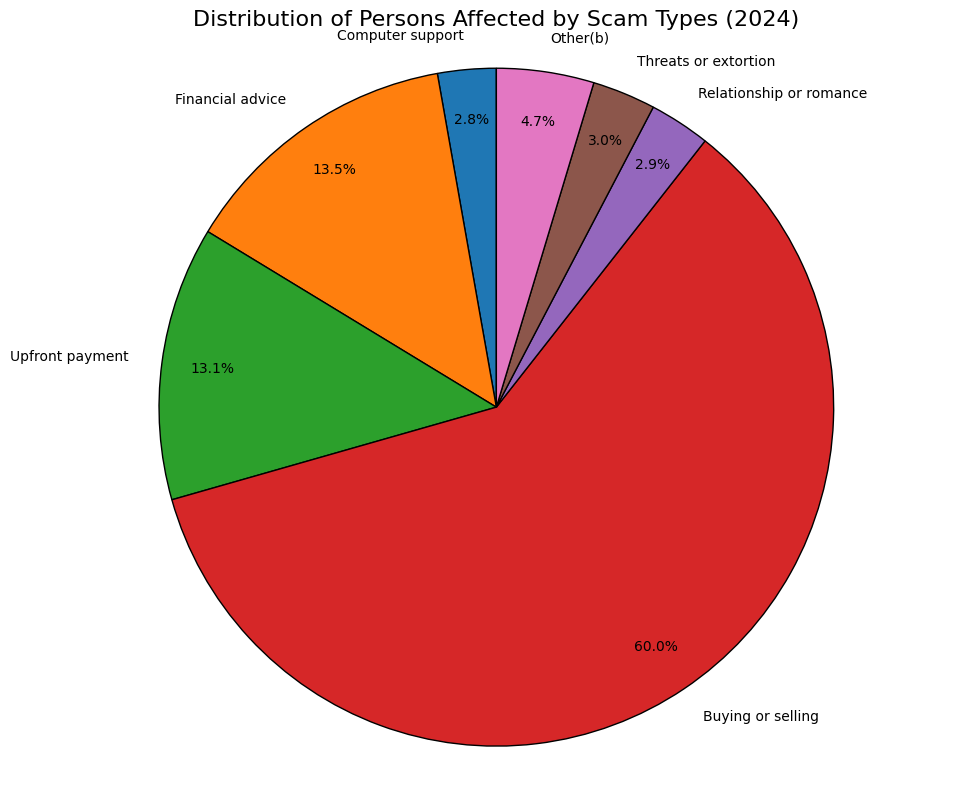

In [26]:
result['Rate 2024 (%)'] = pd.to_numeric(result['Rate 2024 (%)'])

# Prepare data for the pie chart
pie_data_persons = result.set_index('Scam type')['Rate 2024 (%)']

plt.figure(figsize=(10, 8))
plt.pie(pie_data_persons, labels=pie_data_persons.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Persons Affected by Scam Types (2024)', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2025 Scam Data

In [29]:
# Amount data of Scam Type

file_path = "/content/drive/My Drive/LSJM/2025scamwatch.xlsx"
sheet_name = "Sheet2"

df = pd.read_excel(file_path, sheet_name=sheet_name)

df = df[["Scam Type", "Total", "Percentage"]].copy()

df = df.dropna(subset=["Scam Type", "Total"])

df = df[df["Scam Type"] != "Total Amount"]

df["Total"] = (
    df["Total"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Total"] = pd.to_numeric(
    df["Total"], errors="coerce"
)

# Sort in descending order by percentage
df = df.sort_values(by="Percentage", ascending=False).reset_index(drop=True)

display_df = df.copy()
display_df["Total"] = display_df["Total"].map(lambda x: f"${x:,.2f}")
display_df["Percentage"] = display_df["Percentage"].map(lambda x: f"{x*100:.2f}%")

print("\nScam type summary\n")
print(display_df.to_string(index=False))


Scam type summary

                          Scam Type           Total Percentage
                   Investment scams $119,243,620.10     49.94%
                           Phishing  $23,980,230.07     10.04%
           Dating and romance scams  $22,293,925.81      9.34%
                      False billing  $17,757,983.04      7.44%
          Jobs and employment scams  $16,418,717.37      6.88%
   Threats to life, arrest or other  $10,289,330.92      4.31%
                     Shopping scams   $7,579,960.43      3.17%
                     Identity theft   $5,488,378.98      2.30%
                Remote access scams   $3,844,154.19      1.61%
   inheritance and unexpected money   $2,925,531.95      1.23%
                       Rebate scams   $2,817,936.91      1.18%
Betting and sports investment scams   $1,484,059.36      0.62%
            Psychic and clairvoyant   $1,387,633.65      0.58%
                            Hacking     $759,131.88      0.32%
   Travel, prizes and lottery scams

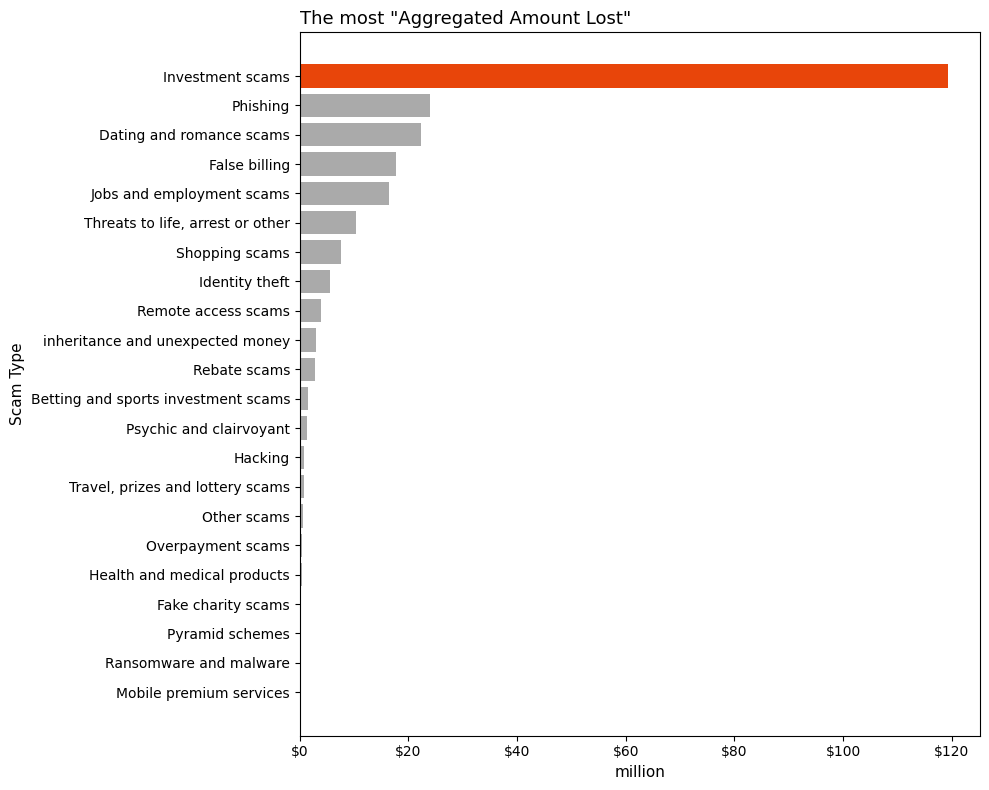

In [30]:
# Plot aggregated amount lost by scam type
plot_df = df.sort_values(by="Total", ascending=True)

colors = ["#E8450A" if s == "Investment scams" else "#AAAAAA" for s in plot_df["Scam Type"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["Scam Type"], plot_df["Total"] / 1_000_000, color=colors)


ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax.set_xlabel("million", fontsize=11)
ax.set_ylabel("Scam Type", fontsize=11)

ax.set_title(
    'The most "Aggregated Amount Lost"',
    fontsize=13, loc="left"
)

plt.tight_layout()
plt.show()

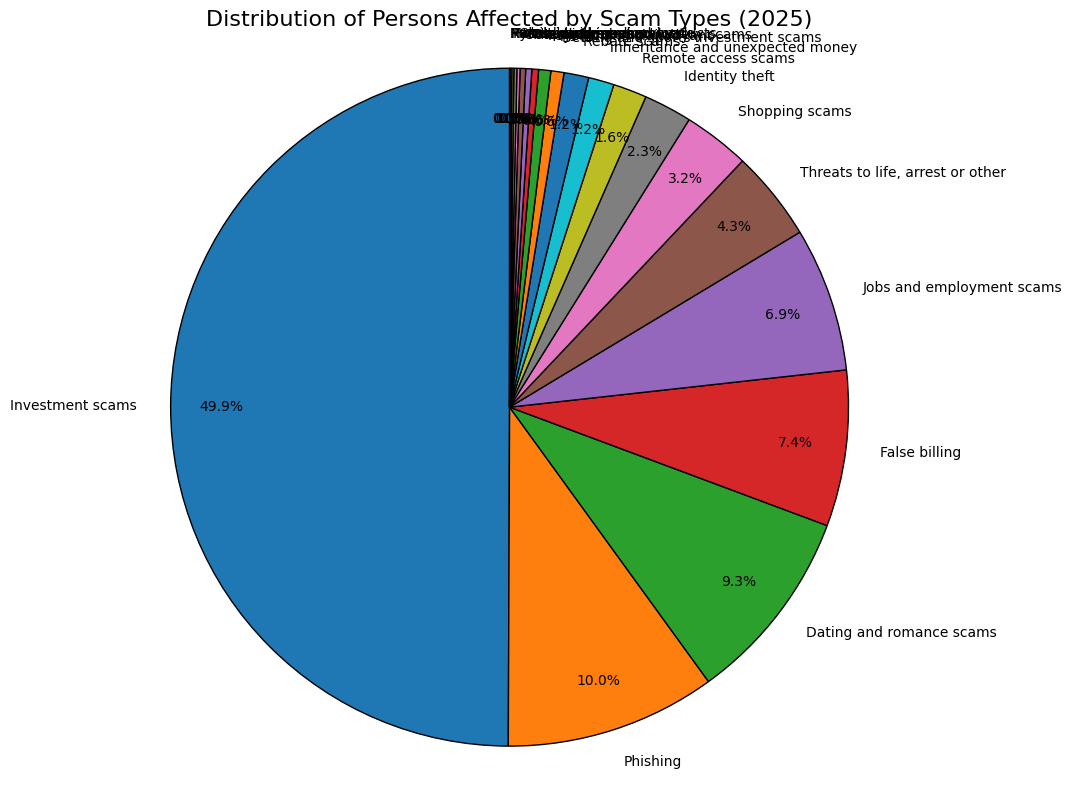

In [36]:
pie_data_2025 = df.set_index('Scam Type')['Percentage']

plt.figure(figsize=(10, 8))
plt.pie(pie_data_2025, labels=pie_data_2025.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Persons Affected by Scam Types (2025)', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
# Amount data of Scam Type

file_path = "/content/drive/My Drive/LSJM/2025scamwatch.xlsx"
sheet_name = "Sheet1"

df = pd.read_excel(file_path, sheet_name=sheet_name)

df = df[["Scam Category", "Total", "Percentage"]].copy()

df = df.dropna(subset=["Scam Category", "Total"])
df = df[~df["Scam Category"].str.strip().isin(["Tota", "Total Amount"])]

df["Total"] = (
    df["Total"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Total"] = pd.to_numeric(
    df["Total"], errors="coerce"
)
df = df.sort_values(by="Percentage", ascending=False).reset_index(drop=True)

display_df = df.copy()
display_df["Total"] = display_df["Total"].map(lambda x: f"${x:,.2f}")
display_df["Percentage"] = display_df["Percentage"].map(lambda x: f"{x*100:.2f}%")

print("\nScam type summary\n")
print(display_df.to_string(index=False))


Scam type summary

                             Scam Category      Total Percentage
Attempts to gain your personal information $73,832.00     51.18%
                         Buying or selling $31,116.00     21.57%
                                     Other $14,695.00     10.19%
                     Threats and extortion  $6,664.00      4.62%
                          Investment scams  $5,150.00      3.57%
                       Jobs and employment  $4,977.00      3.45%
                          Unexpected money  $2,845.00      1.97%
                        Dating and romance  $2,288.00      1.59%
                       Unexpected winnings  $2,098.00      1.45%
                            Fake charities    $602.00      0.42%


/tmp/ipykernel_415/3071731476.py:12: UserWarning: Glyph 21315 (\N{CJK UNIFIED IDEOGRAPH-5343}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21315 (\N{CJK UNIFIED IDEOGRAPH-5343}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


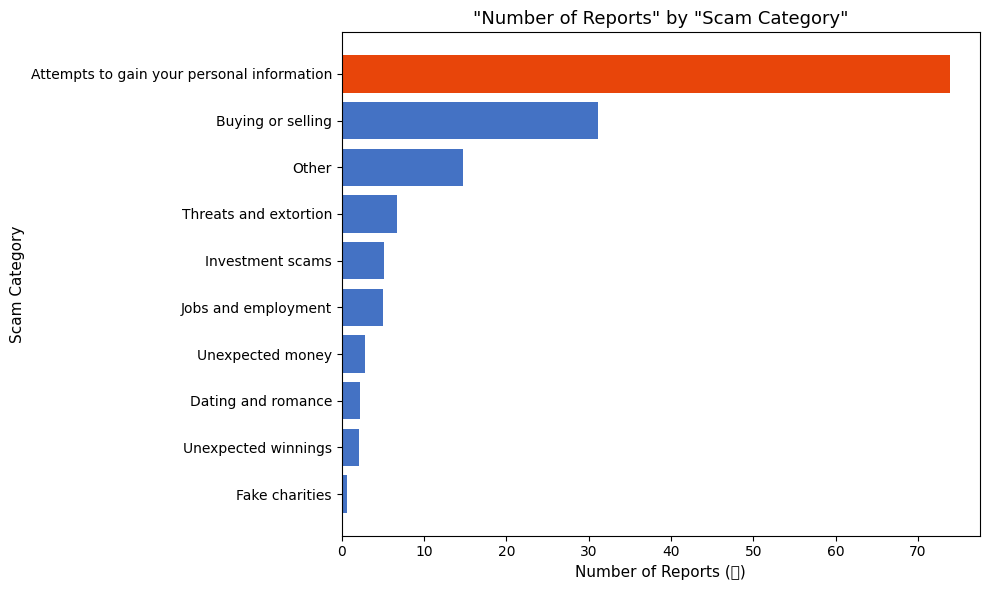

In [ ]:
# Plot aggregated amount lost by scam type
plot_df = df.sort_values(by="Total", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
max_cat = plot_df["Scam Category"].iloc[-1]
colors = ["#E8450A" if s == max_cat else "#4472C4" for s in plot_df["Scam Category"]]
ax.barh(plot_df["Scam Category"], plot_df["Total"] / 1000, color=colors)

ax.set_xlabel("Number of Reports (thousand)", fontsize=11)
ax.set_ylabel("Scam Category", fontsize=11)
ax.set_title('Number of Scam Category', fontsize=13)

plt.tight_layout()
plt.show()

## 2 Features of Phishing Web

### URL Search and Analysis



In [ ]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
path = "/content/drive/MyDrive/LSJM/url dataset.csv"

if os.path.exists(path):
    try:
        df = pd.read_csv(path, encoding='ISO-8859-1')
        print("Original shape:", df.shape)

        cols_to_keep = ["phish_id", "url", "target"]
        df = df[[col for col in cols_to_keep if col in df.columns]]

        df = df.drop_duplicates(subset="url").dropna(subset=["url"])

        print("After cleaning:", df.shape)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")
else:
    print(f"Error：can't find file {path}")
    parent_dir = "/content/drive/MyDrive/LSJM/"
    if os.path.exists(parent_dir):
        print(f"content {parent_dir} have files: \n", os.listdir(parent_dir))
    else:
        print("Please ensure if Google Drive is correct。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (56593, 8)
After cleaning: (56586, 3)


,phish_id,url,target
0,9366067,https://copy-of-rhode-gift-card-lan-436.create...,Other
1,9366053,https://allegrolokalnie.pl-oferta2508073.click,Allegro
2,9366052,http://allegro.pl-822718181826zamowienie272728...,Allegro
3,9366051,http://allegro.pl-oferta57723.click,Allegro
4,9366050,http://allegrolokalnie.pl-591248129512.cyou,Allegro


#### URL Features extraction


Extended feature columns added successfully.


,phish_id,url,target,registered_domain,url_length,hostname_length,path_length,query_length,url_depth,subdomain_count,...,digit_count,letter_count,special_char_count,digit_ratio,letter_ratio,special_char_ratio,entropy,matched_words,matched_word_count,has_redirection
0,9366067,https://copy-of-rhode-gift-card-lan-436.create...,Other,created.app,52,43,1,0,0,1,...,3,37,12,0.057692,0.711538,0.230769,4.276611,[gift],1,0
1,9366053,https://allegrolokalnie.pl-oferta2508073.click,Allegro,pl-oferta2508073.click,46,38,0,0,0,1,...,7,33,6,0.152174,0.717391,0.130435,4.425098,[],0,0
2,9366052,http://allegro.pl-822718181826zamowienie272728...,Allegro,pl-822718181826zamowienie272728m7162728.lat,58,51,0,0,0,1,...,25,27,6,0.431034,0.465517,0.103448,4.213428,[],0,0
3,9366051,http://allegro.pl-oferta57723.click,Allegro,pl-oferta57723.click,35,28,0,0,0,1,...,5,24,6,0.142857,0.685714,0.171429,4.250572,[],0,0
4,9366050,http://allegrolokalnie.pl-591248129512.cyou,Allegro,pl-591248129512.cyou,43,36,0,0,0,1,...,12,25,6,0.279070,0.581395,0.139535,4.452444,[],0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9365956,https://docs.google.com/drawings/d/1MVFdzDcAhH...,Other,google.com,84,15,61,0,4,1,...,6,67,11,0.071429,0.797619,0.130952,5.258289,[],0,0
96,9365955,https://docs.google.com/drawings/d/1QrJpIW-Je9...,Other,google.com,84,15,61,0,4,1,...,12,62,10,0.142857,0.738095,0.119048,5.035017,[],0,0
97,9365954,https://docs.google.com/drawings/d/1kUtY10Vf37...,Other,google.com,84,15,61,0,4,1,...,10,65,9,0.119048,0.773810,0.107143,5.216199,[],0,0
98,9365953,https://docs.google.com/drawings/d/1eCEKNe0zXk...,Other,google.com,84,15,61,0,4,1,...,10,65,9,0.119048,0.773810,0.107143,5.158404,[],0,0



=== Descriptive Statistics ===
         url_length  hostname_length   path_length  query_length  \
count  56586.000000     56586.000000  56586.000000  56586.000000   
mean      60.784505        19.299403     20.648217     11.603524   
std      165.647485        12.980359     34.178536     50.711620   
min       12.000000         0.000000      0.000000      0.000000   
25%       23.000000         8.000000      1.000000      0.000000   
50%       38.000000        16.000000      7.000000      0.000000   
75%       62.000000        25.000000     20.000000      0.000000   
max    25523.000000       110.000000    997.000000   3624.000000   

          url_depth  subdomain_count     dot_count  hyphen_count  \
count  56586.000000     56586.000000  56586.000000  56586.000000   
mean       1.379440         0.750875      1.972149      0.795815   
std        1.575426         0.575686      1.028034      1.397070   
min        0.000000         0.000000      1.000000      0.000000   
25%        0.00

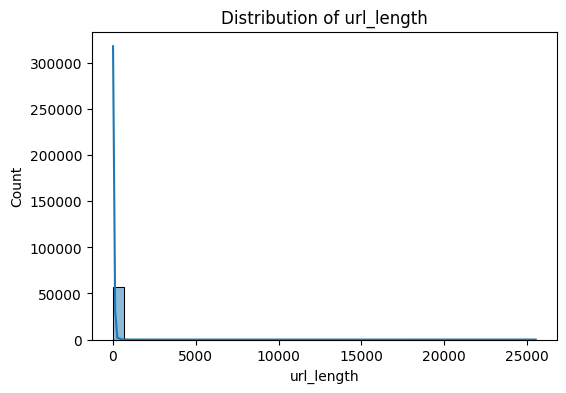

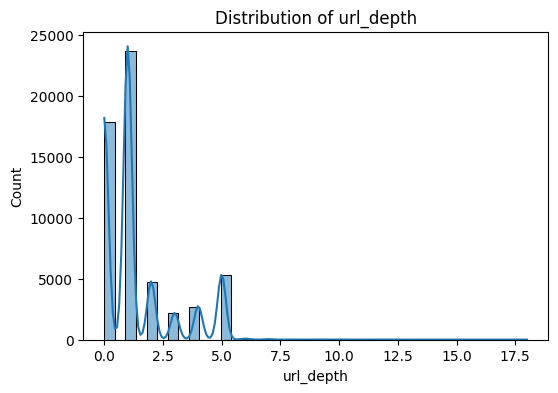

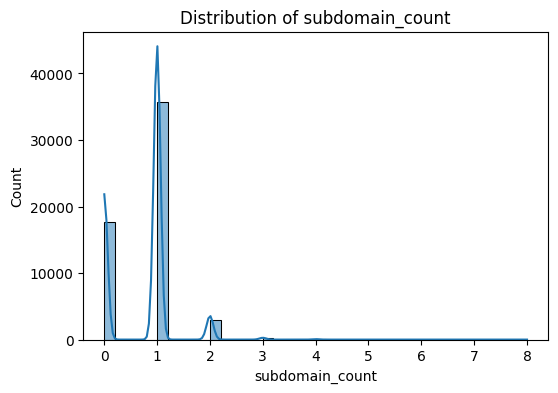

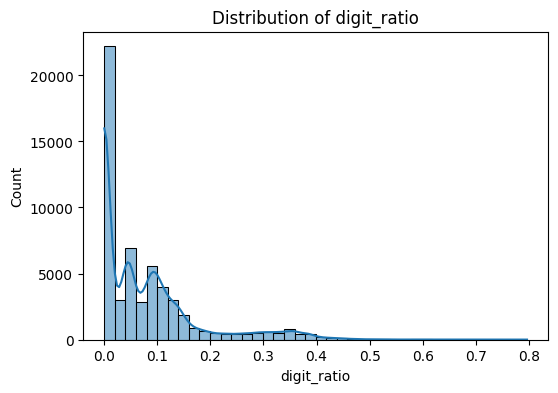

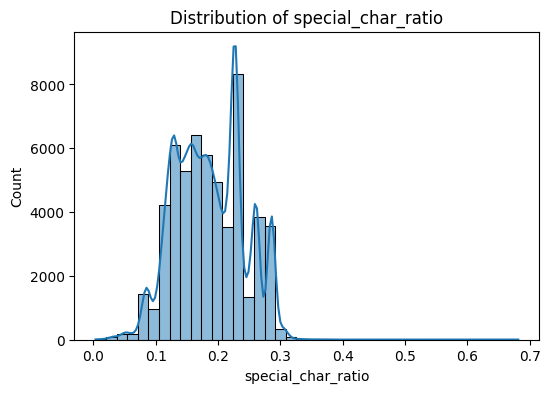

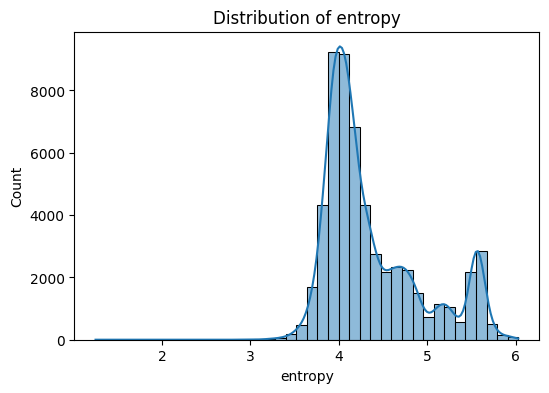

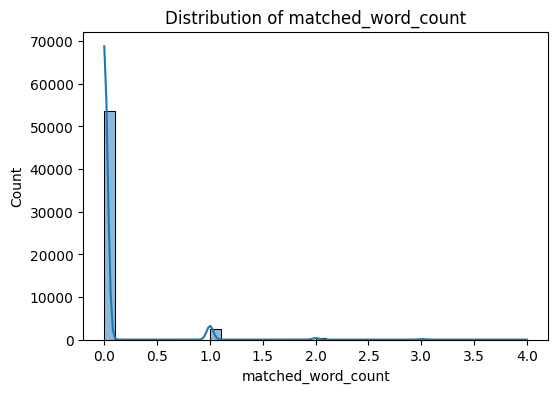


=== Binary Feature Ranking ===
                feature      rate
4              is_https  0.956862
3  has_percent_encoding  0.016046
2       has_redirection  0.013130
1                has_at  0.008695
0                has_ip  0.002845


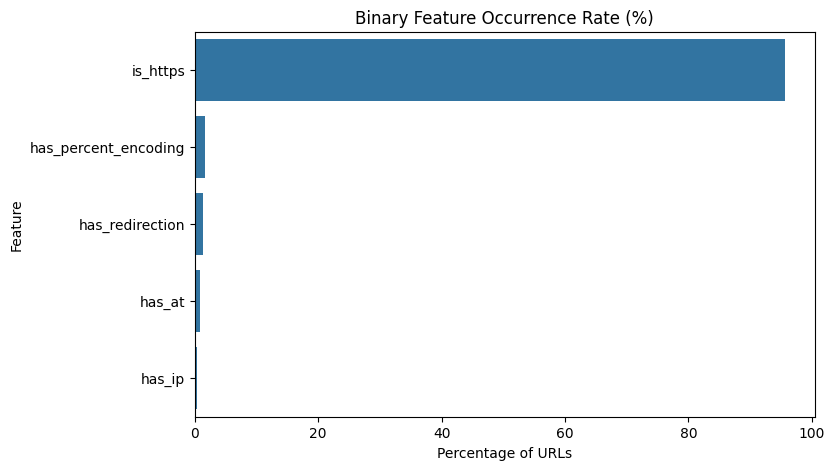

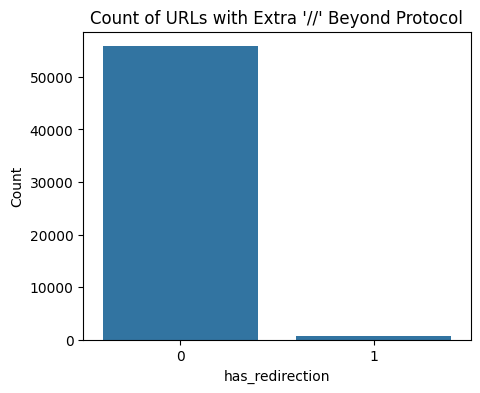


=== Numeric Feature Ranking ===
               feature       mean     median         std        iqr
0           url_length  60.784505  38.000000  165.647485  39.000000
2          path_length  20.648217   7.000000   34.178536  19.000000
1      hostname_length  19.299403  16.000000   12.980359  17.000000
11         digit_count   6.399251   1.000000   23.932097   8.000000
12  special_char_count   9.116725   7.000000    7.108287   3.000000
4            url_depth   1.379440   1.000000    1.575426   2.000000
6            dot_count   1.972149   2.000000    1.028034   1.000000
7         hyphen_count   0.795815   0.000000    1.397070   1.000000
5      subdomain_count   0.750875   1.000000    0.575686   1.000000
9          slash_count   3.758368   3.000000    1.533515   1.000000
15             entropy   4.371819   4.156024    0.555234   0.688239
13         digit_ratio   0.075691   0.045455    0.096880   0.107828
14  special_char_ratio   0.186034   0.183333    0.055054   0.084416
8     underscor

In [ ]:
# =========================
# Step 2: URL Feature Extraction + Extended Lexical Analysis
# =========================

from urllib.parse import urlparse
import tldextract
import re
import pandas as pd
import math
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. High-frequency suspicious words
# -------------------------
HIGH_FREQ_WORDS = [
    "login", "verify", "secure", "update", "account",
    "signin", "confirm", "bank", "wallet", "payment",
    "delivery", "tracking", "parcel", "gift", "reward",
    "crypto", "investment", "support", "alert", "suspend"
]

# -------------------------
# 2. Basic helper functions
# -------------------------
def safe_parse(url):
    """
    Safely parse URL. Return ParseResult or None.
    """
    if not isinstance(url, str) or not url.strip():
        return None
    try:
        return urlparse(url)
    except Exception:
        return None


def get_hostname(url):
    """
    Return hostname without port.
    """
    parsed = safe_parse(url)
    if parsed and parsed.netloc:
        return parsed.netloc.split(":")[0].lower()
    return ""


def get_path(url):
    parsed = safe_parse(url)
    return parsed.path if parsed else ""


def get_query(url):
    parsed = safe_parse(url)
    return parsed.query if parsed else ""


# -------------------------
# 3. Core feature functions
# -------------------------
def domain_of_url(url):
    """
    Return the registered domain, e.g.
    https://login.paypal-secure.top/a -> paypal-secure.top
    """
    if not isinstance(url, str):
        return ""
    ext = tldextract.extract(url)
    if ext.domain and ext.suffix:
        return f"{ext.domain}.{ext.suffix}"
    elif ext.domain:
        return ext.domain
    else:
        return ""


def length_of_url(url):
    """
    Return total URL length.
    """
    if not isinstance(url, str):
        return 0
    return len(url)


def depth_of_url(url):
    """
    Return URL path depth.
    Example:
    https://a.com/aa/bb/cc -> 3
    https://a.com -> 0
    """
    path = get_path(url)
    parts = [p for p in path.split("/") if p]
    return len(parts)


def ip_address_in_url(url):
    """
    Return 1 if URL contains an IPv4 address, else 0.
    """
    if not isinstance(url, str):
        return 0

    pattern = r'(https?://)?(\d{1,3}\.){3}\d{1,3}'
    return 1 if re.search(pattern, url) else 0


def high_freq_words_in_url(url, word_list=HIGH_FREQ_WORDS):
    """
    Return matched suspicious/high-frequency words in URL as a list.
    """
    if not isinstance(url, str):
        return []

    url_lower = url.lower()
    matched = [word for word in word_list if word in url_lower]
    return matched


# =========================================================
# Category 1: Length-based features
# =========================================================
def hostname_length(url):
    return len(get_hostname(url))


def path_length(url):
    return len(get_path(url))


def query_length(url):
    return len(get_query(url))


# =========================================================
# Category 2: Structural features
# =========================================================
def subdomain_count(url):
    """
    Count number of subdomain parts.
    Example:
    a.b.example.com -> 2   (a, b)
    example.com -> 0
    """
    if not isinstance(url, str):
        return 0

    ext = tldextract.extract(url)
    if not ext.subdomain:
        return 0
    return len([x for x in ext.subdomain.split(".") if x])


def dot_count(url):
    if not isinstance(url, str):
        return 0
    return url.count(".")


def hyphen_count(url):
    if not isinstance(url, str):
        return 0
    return url.count("-")


def underscore_count(url):
    if not isinstance(url, str):
        return 0
    return url.count("_")


def slash_count(url):
    """
    Count all '/' in the full URL.
    """
    if not isinstance(url, str):
        return 0
    return url.count("/")


# =========================================================
# Category 3: Symbol / abnormal-format features
# =========================================================
def has_at_symbol(url):
    if not isinstance(url, str):
        return 0
    return 1 if "@" in url else 0


def has_redirection_double_slash(url):
    """
    Return 1 if there is an extra '//' beyond the protocol part.
    Example:
    http://example.com      -> 0
    https://example.com     -> 0
    https://example.com//a  -> 1
    https://a.com/path//b   -> 1
    """
    if not isinstance(url, str) or not url:
        return 0

    url_lower = url.lower()

    if url_lower.startswith("http://"):
        rest = url[7:]   # remove 'http://'
    elif url_lower.startswith("https://"):
        rest = url[8:]   # remove 'https://'
    else:
        rest = url

    return 1 if "//" in rest else 0


def has_percent_encoding(url):
    if not isinstance(url, str):
        return 0
    return 1 if "%" in url else 0


def count_query_symbols(url):
    """
    Count ?, =, & as a rough proxy for query complexity.
    """
    if not isinstance(url, str):
        return 0
    return url.count("?") + url.count("=") + url.count("&")


def is_https(url):
    parsed = safe_parse(url)
    if not parsed:
        return 0
    return 1 if parsed.scheme.lower() == "https" else 0


# =========================================================
# Category 4: Character composition features
# =========================================================
def digit_count(url):
    if not isinstance(url, str):
        return 0
    return sum(c.isdigit() for c in url)


def letter_count(url):
    if not isinstance(url, str):
        return 0
    return sum(c.isalpha() for c in url)


def special_char_count(url):
    """
    Count non-alphanumeric characters.
    """
    if not isinstance(url, str):
        return 0
    return sum(not c.isalnum() for c in url)


def digit_ratio(url):
    if not isinstance(url, str) or len(url) == 0:
        return 0
    return digit_count(url) / len(url)


def letter_ratio(url):
    if not isinstance(url, str) or len(url) == 0:
        return 0
    return letter_count(url) / len(url)


def special_char_ratio(url):
    if not isinstance(url, str) or len(url) == 0:
        return 0
    return special_char_count(url) / len(url)


def shannon_entropy(url):
    """
    Compute Shannon entropy of the URL string.
    Higher entropy often means more randomness / obfuscation.
    """
    if not isinstance(url, str) or len(url) == 0:
        return 0

    counts = Counter(url)
    probs = [count / len(url) for count in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)


# -------------------------
# 4. Apply feature extraction to the dataset
# -------------------------
df["registered_domain"] = df["url"].apply(domain_of_url)

# Category 1: Length features
df["url_length"] = df["url"].apply(length_of_url)
df["hostname_length"] = df["url"].apply(hostname_length)
df["path_length"] = df["url"].apply(path_length)
df["query_length"] = df["url"].apply(query_length)

# Category 2: Structural features
df["url_depth"] = df["url"].apply(depth_of_url)
df["subdomain_count"] = df["url"].apply(subdomain_count)
df["dot_count"] = df["url"].apply(dot_count)
df["hyphen_count"] = df["url"].apply(hyphen_count)
df["underscore_count"] = df["url"].apply(underscore_count)
df["slash_count"] = df["url"].apply(slash_count)

# Category 3: Symbol / abnormal-format features
df["has_ip"] = df["url"].apply(ip_address_in_url)
df["has_at"] = df["url"].apply(has_at_symbol)
df["has_redirection"] = df["url"].apply(has_redirection_double_slash)
df["has_percent_encoding"] = df["url"].apply(has_percent_encoding)
df["query_symbol_count"] = df["url"].apply(count_query_symbols)
df["is_https"] = df["url"].apply(is_https)

# Category 4: Character composition features
df["digit_count"] = df["url"].apply(digit_count)
df["letter_count"] = df["url"].apply(letter_count)
df["special_char_count"] = df["url"].apply(special_char_count)
df["digit_ratio"] = df["url"].apply(digit_ratio)
df["letter_ratio"] = df["url"].apply(letter_ratio)
df["special_char_ratio"] = df["url"].apply(special_char_ratio)
df["entropy"] = df["url"].apply(shannon_entropy)

# Suspicious words
df["matched_words"] = df["url"].apply(high_freq_words_in_url)
df["matched_word_count"] = df["matched_words"].apply(len)

print("Extended feature columns added successfully.")
display(df.head(100))


# -------------------------
# 5. Basic descriptive statistics
# -------------------------
selected_cols = [
    "url_length", "hostname_length", "path_length", "query_length",
    "url_depth", "subdomain_count", "dot_count", "hyphen_count",
    "underscore_count", "slash_count",
    "has_ip", "has_at", "has_redirection", "has_percent_encoding",
    "query_symbol_count", "is_https",
    "digit_count", "letter_count", "special_char_count",
    "digit_ratio", "letter_ratio", "special_char_ratio",
    "entropy", "matched_word_count"
]

print("\n=== Descriptive Statistics ===")
print(df[selected_cols].describe())

print("\n=== Binary Feature Rates (%) ===")
binary_cols = ["has_ip", "has_at", "has_redirection", "has_percent_encoding", "is_https"]
for col in binary_cols:
    print(f"{col}: {df[col].mean() * 100:.2f}%")


# -------------------------
# 6. Numeric feature visualization
# -------------------------
num_cols_to_plot = [
    "url_length", "url_depth", "subdomain_count",
    "digit_ratio", "special_char_ratio", "entropy",
    "matched_word_count"
]

for col in num_cols_to_plot:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


# -------------------------
# 7. Binary feature ranking
# -------------------------
binary_rank = pd.DataFrame({
    "feature": binary_cols,
    "rate": [df[col].mean() for col in binary_cols]
}).sort_values("rate", ascending=False)

print("\n=== Binary Feature Ranking ===")
print(binary_rank)


# -------------------------
# 8. Binary feature visualization
# -------------------------
binary_rates = pd.DataFrame({
    "feature": binary_cols,
    "rate": [df[col].mean() * 100 for col in binary_cols]
}).sort_values("rate", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=binary_rates, x="rate", y="feature")
plt.title("Binary Feature Occurrence Rate (%)")
plt.xlabel("Percentage of URLs")
plt.ylabel("Feature")
plt.show()


# Optional: single visualization for redirection feature
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="has_redirection")
plt.title("Count of URLs with Extra '//' Beyond Protocol")
plt.xlabel("has_redirection")
plt.ylabel("Count")
plt.show()


# -------------------------
# 9. Numeric feature ranking
# -------------------------
numeric_cols = [
    "url_length", "hostname_length", "path_length", "query_length",
    "url_depth", "subdomain_count", "dot_count", "hyphen_count",
    "underscore_count", "slash_count", "query_symbol_count",
    "digit_count", "special_char_count", "digit_ratio",
    "special_char_ratio", "entropy", "matched_word_count"
]

summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    summary.append({
        "feature": col,
        "mean": df[col].mean(),
        "median": df[col].median(),
        "std": df[col].std(),
        "iqr": iqr
    })

numeric_rank = pd.DataFrame(summary).sort_values("iqr", ascending=False)

print("\n=== Numeric Feature Ranking ===")
print(numeric_rank)

#### Scoring criteria

In [ ]:
def phishing_risk_score(row):
    score = 0

    # A. High-risk anomaly features
    if row["has_ip"] == 1:
        score += 20
    if row["has_at"] == 1:
        score += 18
    if row["has_redirection"] == 1:
        score += 15
    if row["has_percent_encoding"] == 1:
        score += 12

    # B. Structural complexity features
    # url_length
    if row["url_length"] > 100:
        score += 12
    elif row["url_length"] > 62:
        score += 8
    elif row["url_length"] > 38:
        score += 4

    # path_length
    if row["path_length"] > 50:
        score += 10
    elif row["path_length"] > 26:
        score += 7
    elif row["path_length"] > 7:
        score += 4

    # hostname_length
    if row["hostname_length"] > 33:
        score += 6
    elif row["hostname_length"] > 16:
        score += 3

    # url_depth
    if row["url_depth"] >= 4:
        score += 8
    elif row["url_depth"] >= 2:
        score += 4

    # subdomain_count
    if row["subdomain_count"] >= 2:
        score += 6
    elif row["subdomain_count"] == 1:
        score += 2

    # C. Character obfuscation features
    # digit_ratio
    if row["digit_ratio"] > 0.15:
        score += 8
    elif row["digit_ratio"] > 0.045:
        score += 4

    # special_char_ratio
    if row["special_char_ratio"] > 0.27:
        score += 6
    elif row["special_char_ratio"] > 0.18:
        score += 3

    # entropy
    if row["entropy"] > 4.85:
        score += 8
    elif row["entropy"] > 4.15:
        score += 4

    return min(score, 100)


def risk_level(score):
    if score >= 75:
        return "Very High Risk"
    elif score >= 50:
        return "High Risk"
    elif score >= 25:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_score"] = df.apply(phishing_risk_score, axis=1)
df["risk_level"] = df["risk_score"].apply(risk_level)


IndentationError: expected an indented block after function definition on line 76 (2472841590.py, line 77)

### Txt Analysis

In [3]:
import os
import re
import time
import sqlite3
import warnings
import pandas as pd
import requests
import nltk
import spacy

from urllib.parse import urlparse
from collections import Counter
from bs4 import BeautifulSoup
from google.colab import drive
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

In [4]:
# Configuration area
PHISHTANK_CSV_PATH = "/content/drive/MyDrive/LSJM/url dataset.csv"
TARGET_VALID_PAGES = 200
SAVE_DIR = "data"

CSV_OUTPUT = os.path.join(SAVE_DIR, "phishing_150_dataset.csv")
DB_OUTPUT = os.path.join(SAVE_DIR, "phishing_150.db")

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome Safari/537.36"
}

REQUEST_TIMEOUT = 15
os.makedirs(SAVE_DIR, exist_ok=True)

# Common interception warnings close page keywords
WARNING_PATTERNS = [
    "deceptive site ahead",
    "security warning",
    "malware ahead",
    "suspicious site",
    "phishing warning",
    "unsafe website",
    "access denied",
    "forbidden",
    "blocked",
    "website blocked"
]

CLOSED_PATTERNS = [
    "404 not found",
    "403 forbidden",
    "page not found",
    "service unavailable",
    "temporarily unavailable",
    "domain parked",
    "account suspended",
    "expired domain",
    "this site can’t be reached",
    "server not found"
]

# Utility function
def load_phishtank_csv(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    if "url" not in df.columns:
        raise ValueError("CSV do not have url")

    keep_cols = [c for c in [
        "phish_id", "url", "phish_detail_url", "submission_time",
        "verified", "verification_time", "online", "target"
    ] if c in df.columns]

    df = df[keep_cols].copy()
    df["url"] = df["url"].astype(str).str.strip()
    df = df.dropna(subset=["url"])
    df = df[df["url"] != ""]
    df = df.drop_duplicates(subset=["url"]).reset_index(drop=True)

    return df


def extract_visible_text(html):
    soup = BeautifulSoup(html, "lxml")

    for tag in soup([
        "script", "style", "noscript", "svg", "canvas", "footer", "header",
        "meta", "link", "iframe", "img", "picture", "source"
    ]):
        tag.decompose()

    candidate_tags = soup.find_all([
        "title", "h1", "h2", "h3", "h4", "h5", "h6",
        "p", "li", "a", "button", "label", "span", "div"
    ])

    texts = []
    for tag in candidate_tags:
        text = tag.get_text(" ", strip=True)
        if not text:
            continue

        if len(text) < 2:
            continue

        texts.append(text)

    text = " ".join(texts)

    text = re.sub(r"&[a-z]+;", " ", text)

    text = re.sub(r"http\S+|www\.\S+", " ", text)

    text = re.sub(r"\{[^{}]{0,200}\}", " ", text)
    text = re.sub(r"[.#][A-Za-z0-9_-]+", " ", text)
    text = re.sub(r"[A-Za-z-]+\s*:\s*[^;]+;?", " ", text)
    text = re.sub(r"\b\d+(px|rem|em|vh|vw|%)\b", " ", text)
    text = re.sub(r"\b(rgba?|hsla?)\b", " ", text)
    text = re.sub(r"&quot;|quot;|&amp;|nbsp;", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text


def is_warning_or_closed(text):
    text = (text or "").lower()

    for p in WARNING_PATTERNS:
        if p in text:
            return True, "warning_page"

    for p in CLOSED_PATTERNS:
        if p in text:
            return True, "closed_page"

    return False, "ok"


def fetch_page(url, session):
    try:
        resp = session.get(
            url,
            headers=HEADERS,
            timeout=REQUEST_TIMEOUT,
            allow_redirects=True,
            verify=False
        )

        final_url = resp.url
        status_code = resp.status_code
        content_type = resp.headers.get("Content-Type", "")

        html = ""
        if "text/html" in content_type.lower() or "<html" in resp.text.lower():
            html = resp.text

        return {
            "original_url": url,
            "final_url": final_url,
            "status_code": status_code,
            "content_type": content_type,
            "html": html,
            "error": None
        }

    except Exception as e:
        return {
            "original_url": url,
            "final_url": None,
            "status_code": None,
            "content_type": None,
            "html": "",
            "error": str(e)
        }

def is_technical_noise_text(text):
    if not text:
        return True

    low = text.lower()

    bad_patterns = [
        r"\bvar\b", r"\bhover\b", r"\btransparent\b", r"\binherit\b",
        r"\bbackground\b", r"\bborder\b", r"\bopacity\b", r"\bcontent\b",
        r"\bcss\b", r"\bhtml\b", r"\bbody\b", r"\bdiv\b", r"\bspan\b",
        r"\bquot\b", r"\bprose\b", r"\bdark\b"
    ]

    hits = 0
    for p in bad_patterns:
        hits += len(re.findall(p, low))

    words = re.findall(r"[a-zA-Z]+", low)
    if len(words) == 0:
        return True

    ratio = hits / len(words)

    return ratio > 0.12

def is_valid_page(page):
    if page["status_code"] != 200:
        return False, "bad_status"

    html = page["html"]
    if not html or len(html) < 200:
        return False, "empty_html"

    text = extract_visible_text(html)
    if len(text) < 80:
        return False, "too_little_text"

    bad, reason = is_warning_or_closed(text)
    if bad:
        return False, reason

    if is_technical_noise_text(text):
        return False, "too_technical"

    return True, "valid"

# Build Dataset

def build_dataset(df_urls, target_n=150):
    session = requests.Session()
    session.verify = False

    records = []
    seen_final_urls = set()

    for idx, row in df_urls.iterrows():
        if len(records) >= target_n:
            break

        url = row["url"]
        phish_id = row["phish_id"] if "phish_id" in row else None
        target_brand = row["target"] if "target" in row else None

        page = fetch_page(url, session)
        ok, reason = is_valid_page(page)

        if not ok:
            if idx % 50 == 0:
                print(f"[SKIP] {idx} -> {reason}")
            continue

        final_url = page["final_url"]
        if final_url in seen_final_urls:
            continue

        seen_final_urls.add(final_url)
        page_text_raw = extract_visible_text(page["html"])

        records.append({
            "phish_id": phish_id,
            "target_brand": target_brand,
            "original_url": url,
            "final_url": final_url,
            "status_code": page["status_code"],
            "content_type": page["content_type"],
            "page_text_raw": page_text_raw
        })

        if len(records) % 25 == 0:
            print(f"[INFO] valid pages collected: {len(records)} / {target_n}")

        time.sleep(0.3)

    return pd.DataFrame(records)

# Save in database
def save_to_csv_and_db(df, csv_path, db_path):
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"[INFO] CSV saved to: {csv_path}")

    conn = sqlite3.connect(db_path)
    df.to_sql("phishing_pages_150", conn, if_exists="replace", index=False)
    conn.close()
    print(f"[INFO] SQLite DB saved to: {db_path}")


def main():
    print("[STEP 1] loading PhishTank CSV...")
    df_urls = load_phishtank_csv(PHISHTANK_CSV_PATH)
    print(f"[INFO] total candidate urls: {len(df_urls)}")

    print("[STEP 2] collecting valid phishing pages...")
    dataset_df = build_dataset(df_urls, TARGET_VALID_PAGES)
    print(f"[INFO] final valid pages: {len(dataset_df)}")

    if len(dataset_df) == 0:
        print("[ERROR] no valid pages collected")
        return

    print("[STEP 3] saving dataset...")
    save_to_csv_and_db(dataset_df, CSV_OUTPUT, DB_OUTPUT)

    print("[DONE] dataset build finished")


if __name__ == "__main__":
    main()

[STEP 1] loading PhishTank CSV...
[INFO] total candidate urls: 56561
[STEP 2] collecting valid phishing pages...
[SKIP] 0 -> bad_status
[SKIP] 50 -> bad_status
[SKIP] 100 -> too_little_text
[INFO] valid pages collected: 25 / 200


KeyboardInterrupt: 

In [5]:
# Make sure have saved in database
print(os.getcwd())
print(os.path.abspath("data/phishing_150_dataset.csv"))
print(os.path.abspath("data/phishing_150.db"))

/content
/content/data/phishing_150_dataset.csv
/content/data/phishing_150.db


In [6]:
excel_path = "/content/drive/MyDrive/LSJM/phishing_150_dataset.xlsx"
excel_output_path = "/content/drive/MyDrive/LSJM/phishing_word_frequency.xlsx"

df = pd.read_excel(excel_path)

print("LIST NAME", df.columns.tolist())

texts = df["page_text_raw"].dropna().astype(str)

all_text = " ".join(texts)

words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

word_counts = Counter(words)

freq_df = pd.DataFrame(word_counts.items(), columns=["word", "frequency"])
freq_df = freq_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)

freq_df.to_excel(excel_output_path, index=False)

print("Excel output path", excel_output_path)
print(freq_df.head(20))

LIST NAME ['phish_id', 'target_brand', 'original_url', 'final_url', 'status_code', 'content_type', 'page_text_raw']
Excel output path /content/drive/MyDrive/LSJM/phishing_word_frequency.xlsx
        word  frequency
0         to       1245
1       your        809
2         in        700
3        you        699
4     google        686
5        the        661
6      email        602
7        and        570
8         de        562
9          a        509
10       tab        473
11      file        458
12        no        416
13  continue        389
14      with        381
15        or        349
16   website        332
17       for        325
18      will        322
19        of        320


In [7]:
from collections import Counter
from nltk.corpus import stopwords

nltk.download("stopwords")

excel_path = "/content/drive/MyDrive/LSJM/phishing_150_dataset.xlsx"
excel_output_path = "/content/drive/MyDrive/LSJM/phishing_word_frequency_no_stopwords.xlsx"

df = pd.read_excel(excel_path)
texts = df["page_text_raw"].dropna().astype(str)
all_text = " ".join(texts)

words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

stop_words = set(stopwords.words("english"))
words = [w for w in words if w not in stop_words and len(w) > 1]

word_counts = Counter(words)

freq_df = pd.DataFrame(word_counts.items(), columns=["word", "frequency"])
freq_df = freq_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)

freq_df.to_excel(excel_output_path, index=False)

print("Excel output path", excel_output_path)
print(freq_df.head(20))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Excel output path /content/drive/MyDrive/LSJM/phishing_word_frequency_no_stopwords.xlsx
        word  frequency
0     google        686
1      email        602
2         de        562
3        tab        473
4       file        458
5   continue        389
6    website        332
7    cookies        294
8       sign        291
9       open        283
10      maps        266
11       yes        266
12       use        265
13        id        257
14      bank        244
15      page        234
16        en        222
17  password        214
18   browser        202
19      link        192


In [8]:
excel_path = "/content/drive/MyDrive/LSJM/phishing_150_dataset.xlsx"
excel_output_path = "/content/drive/MyDrive/LSJM/phishing_word_frequency_no_stopwords.xlsx"

df = pd.read_excel(excel_path)
texts = df["page_text_raw"].dropna().astype(str)
all_text = " ".join(texts)

words = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())

stop_words = set(stopwords.words("english"))
words = [w for w in words if w not in stop_words and len(w) > 1]

word_counts = Counter(words)

freq_df = pd.DataFrame(word_counts.items(), columns=["word", "frequency"])
freq_df = freq_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)

freq_df.to_excel(excel_output_path, index=False)

print("Excel has been exported：", excel_output_path)
print(freq_df.head(20))

Excel has been exported： /content/drive/MyDrive/LSJM/phishing_word_frequency_no_stopwords.xlsx
        word  frequency
0     google        686
1      email        602
2         de        562
3        tab        473
4       file        458
5   continue        389
6    website        332
7    cookies        294
8       sign        291
9       open        283
10      maps        266
11       yes        266
12       use        265
13        id        257
14      bank        244
15      page        234
16        en        222
17  password        214
18   browser        202
19      link        192


In [9]:
# Download related documents
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("averaged_perceptron_tagger")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [10]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag

from wordcloud import WordCloud
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# configuration area
SCAM_LEXICON = {
    "financial": [
        "bank", "account", "payment", "invoice", "credit", "debit",
        "transfer", "transaction", "wallet", "refund", "tax",
        "billing", "card", "crypto", "loan", "cash", "salary"
    ],
    "romance": [
        "love", "dear", "relationship", "baby", "darling",
        "romance", "trust", "heart", "marriage"
    ],
    "job": [
        "job", "career", "hiring", "recruitment", "position",
        "vacancy", "interview", "resume", "cv"
    ],
    "delivery": [
        "parcel", "delivery", "shipment", "tracking",
        "courier", "package", "post"
    ],
    "account_security": [
        "verify", "verification", "password", "login", "signin",
        "confirm", "security", "authenticate", "credential", "otp", "code"
    ],
    "urgency": [
        "urgent", "immediately", "suspend", "limited", "alert",
        "warning", "expire", "deadline", "now"
    ]
}

DATA_PATH = "/content/drive/MyDrive/LSJM/phishing_150_dataset.xlsx"
READ_FROM = "excel"

OUTPUT_DIR = "/content/drive/MyDrive/LSJM/analysis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# read data
def load_dataset():
    if READ_FROM == "excel":
        df = pd.read_excel(DATA_PATH)
    elif READ_FROM == "csv":
        df = pd.read_csv(DATA_PATH)
    else:
        raise ValueError("READ_FROM must be 'excel' or 'csv'")
    return df


# data clean
def clean_text_basic(text):
    if pd.isna(text):
        return ""

    text = str(text).strip()
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = text.replace("\xa0", " ")
    text = text.replace("\\", " ")
    text = re.sub(r"\s+", " ", text)

    text = re.sub(r"[^A-Za-z0-9\s\.,!?:;@#\-/]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def tokenize_and_filter(text):
    TECH_TOKENS = {
        "var", "quot", "hover", "transparent", "inherit", "content",
        "dark", "prose", "none", "block", "inline", "border",
        "background", "color", "opacity", "supports", "rem", "px",
        "css", "html", "body", "div", "span", "button", "input",
        "label", "form", "code"
    }

    tokens = word_tokenize(text.lower())
    filtered = []

    for tok in tokens:
        tok = tok.strip()

        if not tok:
            continue
        if tok in STOP_WORDS:
            continue
        if tok in TECH_TOKENS:
            continue
        if re.fullmatch(r"[\W_]+", tok):
            continue
        if len(tok) <= 1:
            continue

        if tok.startswith(".") or tok.startswith("/"):
            continue
        if re.fullmatch(r"\d+(\.\d+)?", tok):
            continue
        if re.fullmatch(r"\d+(px|rem|em|vh|vw|%)", tok):
            continue
        if re.search(r"[a-z]+-[a-z0-9-]+", tok):
            continue
        if re.search(r"\d", tok) and len(tok) > 3:
            continue
        if tok.startswith("data-") or tok.startswith("tw-"):
            continue

        filtered.append(tok)

    return filtered


def preprocess_dataframe(df):
    df = df.copy()

    df = df.dropna(subset=["page_text_raw", "final_url"])
    df["page_text_clean"] = df["page_text_raw"].astype(str).apply(clean_text_basic)
    df = df[df["page_text_clean"].str.strip() != ""]
    df = df.drop_duplicates(subset=["final_url"]).reset_index(drop=True)

    df["tokens"] = df["page_text_clean"].apply(tokenize_and_filter)
    df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

    return df

# NLP Analytics
def compute_word_frequencies(df):
    all_tokens = []
    for toks in df["tokens"]:
        all_tokens.extend(toks)
    return Counter(all_tokens)


def pos_tag_top_words(counter_obj, top_n=100):
    words = [w for w, _ in counter_obj.most_common(top_n)]
    return pos_tag(words)


def get_wordnet_group(word):
    synsets = wordnet.synsets(word)
    lemmas = set()

    for syn in synsets[:3]:
        for lemma in syn.lemmas():
            lemmas.add(lemma.name().lower().replace("_", " "))

    return list(lemmas)


def classify_token_category(token):
    token = token.lower()

    for cat, vocab in SCAM_LEXICON.items():
        if token in vocab:
            return cat

        syns = get_wordnet_group(token)
        if set(syns) & set(vocab):
            return cat

    return "other"


def category_statistics(counter_obj, top_n=300):
    stats = defaultdict(int)

    for word, freq in counter_obj.most_common(top_n):
        cat = classify_token_category(word)
        stats[cat] += freq

    return dict(stats)


# BERT
def load_major_job_reference():
    majors = [
        {
            "major_name": "Computer Science",
            "major_description": "Programming, algorithms, software engineering, machine learning, databases, computer systems, data analysis"
        },
        {
            "major_name": "Finance",
            "major_description": "Banking, investment, financial analysis, accounting, markets, risk, payment systems"
        },
        {
            "major_name": "Psychology",
            "major_description": "Human behavior, emotion, relationships, counseling, social interaction, trust, persuasion"
        },
        {
            "major_name": "Business Analytics",
            "major_description": "Data analysis, business intelligence, dashboards, forecasting, decision making, optimization"
        },
        {
            "major_name": "Cyber Security",
            "major_description": "Threat intelligence, phishing, malware, digital security, authentication, fraud detection, incident response"
        },
    ]

    jobs = [
        {
            "job_name": "Fraud Analyst",
            "job_description": "Analyze suspicious transactions, identify scam patterns, monitor alerts, investigate financial fraud and phishing activity"
        },
        {
            "job_name": "Cyber Security Analyst",
            "job_description": "Detect phishing websites, analyze malicious activity, perform threat intelligence, support secure authentication and account protection"
        },
        {
            "job_name": "Customer Support Agent",
            "job_description": "Help users resolve account access, billing, delivery, login, and payment issues"
        },
        {
            "job_name": "Recruitment Consultant",
            "job_description": "Hiring, candidate screening, interviews, job matching, recruitment operations"
        }
    ]

    return pd.DataFrame(majors), pd.DataFrame(jobs)


def score_job_major_matching(majors_df, jobs_df):
    major_emb = EMBED_MODEL.encode(majors_df["major_description"].tolist(), show_progress_bar=False)
    job_emb = EMBED_MODEL.encode(jobs_df["job_description"].tolist(), show_progress_bar=False)

    sims = cosine_similarity(job_emb, major_emb)

    rows = []
    for i, job_row in jobs_df.iterrows():
        for j, major_row in majors_df.iterrows():
            rows.append({
                "job_name": job_row["job_name"],
                "major_name": major_row["major_name"],
                "match_score": float(sims[i, j])
            })

    return pd.DataFrame(rows)


def cluster_match_scores(score_df):
    score_df = score_df.copy()
    arr = score_df[["match_score"]].values

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    score_df["cluster"] = kmeans.fit_predict(arr)

    centers = kmeans.cluster_centers_.flatten()
    order = centers.argsort()

    cluster_map = {
        order[0]: "low",
        order[1]: "medium",
        order[2]: "high"
    }

    score_df["match_level"] = score_df["cluster"].map(cluster_map)
    return score_df

In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

category_df = freq_df.copy()
category_df["category"] = category_df["word"].apply(classify_token_category)

all_words_df = category_df.copy()
words = all_words_df["word"].astype(str).tolist()

print("Total amount of words:", len(words))
print(all_words_df.head())

# 1. Word vector model
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(words, show_progress_bar=True)

# 2. KMeans Cluster
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

all_words_df["kmeans_cluster"] = cluster_labels

print("\nKMeans Table:")
print(all_words_df.head(20))

Total amount of words: 2566
     word  frequency category
0  google        686    other
1   email        602    other
2      de        562    other
3     tab        473    other
4    file        458    other


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/81 [00:00<?, ?it/s]


KMeans Table:
        word  frequency          category  kmeans_cluster
0     google        686             other               3
1      email        602             other               4
2         de        562             other               2
3        tab        473             other               3
4       file        458             other               4
5   continue        389             other               4
6    website        332             other               3
7    cookies        294             other               1
8       sign        291             other               5
9       open        283             other               4
10      maps        266             other               3
11       yes        266             other               5
12       use        265             other               4
13        id        257             other               4
14      bank        244         financial               8
15      page        234             other               4

In [14]:
# The specific words of each category
for c in sorted(all_words_df["kmeans_cluster"].unique()):
    cluster_part = all_words_df[all_words_df["kmeans_cluster"] == c] \
        .sort_values("frequency", ascending=False)

    print(f"\n===== KMeans Cluster {c} =====")
    print(cluster_part[["word", "frequency", "category"]].head(30))


===== KMeans Cluster 0 =====
            word  frequency category
78     seguridad         88    other
136      paribas         51    other
134     agricole         51    other
157          por         45    other
161          que         44    other
170         dito         42    other
188        sitio         38    other
195       correo         36    other
210        konto         33    other
253        datos         27    other
287   selecionar         24    other
329     usuarios         22    other
352       equipo         21    other
374    identidad         19    other
369           es         19    other
386        suomi         18    other
396     italiano         18    other
407     filipino         17    other
426  identifiant         16    other
431      minutos         16    other
443         sido         16    other
454      usuario         15    other
465  finansowego         15    other
484      vendido         15    other
502   nacimiento         14    other
510    e

In [15]:
# Cluster Rename
cluster_name_map = {
    5: "web_technical",
    0: "account_security",
    3: "international",
    8: "CTA",
    9: "information_gudience",
    1: "action",
    6: "financial",
    2: "stop_words",
    7: "small_language",
    4: "delivery"
}

all_words_df["cluster_name"] = all_words_df["kmeans_cluster"].map(cluster_name_map)

# Gather
named_cluster_stats = all_words_df.groupby("cluster_name", as_index=False)["frequency"].sum()
named_cluster_stats = named_cluster_stats.sort_values("frequency", ascending=False).reset_index(drop=True)

print("\nCluster statistics after naming ：")
print(named_cluster_stats)


Cluster statistics after naming ：
           cluster_name  frequency
0              delivery       7547
1         international       5517
2         web_technical       5139
3            stop_words       4123
4                action       3449
5                   CTA       3241
6  information_gudience       3155
7      account_security       1917
8        small_language       1895
9             financial       1607


In [16]:
# Delete 'stop_words' group
filtered_named_cluster_stats = named_cluster_stats[named_cluster_stats['cluster_name'] != 'stop_words'].reset_index(drop=True)

print()
display(filtered_named_cluster_stats)

,cluster_name,frequency
0,delivery,7547
1,international,5517
2,web_technical,5139
3,action,3449
4,CTA,3241
5,information_gudience,3155
6,account_security,1917
7,small_language,1895
8,financial,1607


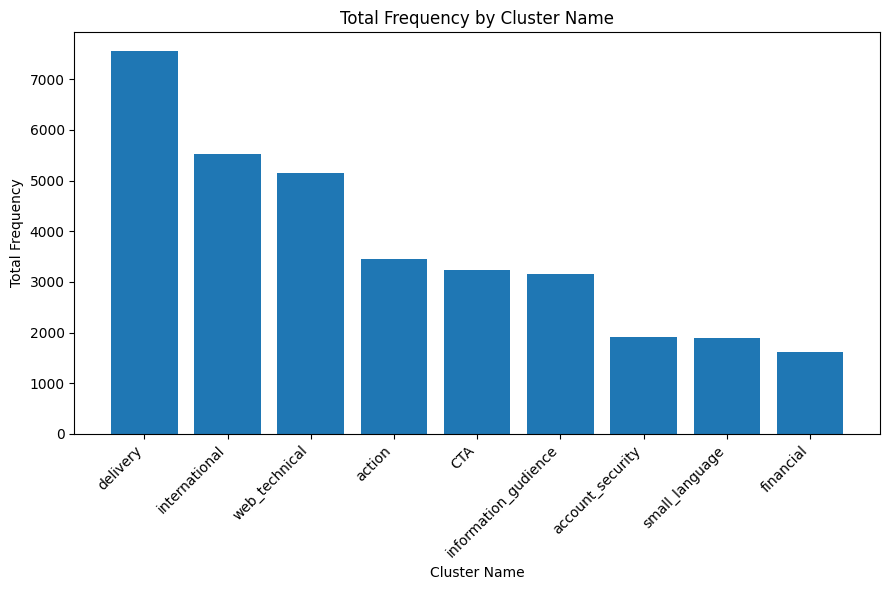

In [17]:
# Plot Total Frequency by Cluster Name
plt.figure(figsize=(9, 6))
plt.bar(filtered_named_cluster_stats["cluster_name"], filtered_named_cluster_stats["frequency"])
plt.xlabel("Cluster Name")
plt.ylabel("Total Frequency")
plt.title("Total Frequency by Cluster Name")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
# Delete 'stop_words' group in Data Base

if 'filtered_named_cluster_stats' in locals():
    conn = sqlite3.connect(DB_OUTPUT)
    filtered_named_cluster_stats.to_sql("phishing_categories_no_stopwords", conn, if_exists="replace", index=False)
    conn.close()
    print(f"Put 'stop_words' the category statistics of xx to the database table 'phishing_categories_no_stopwords'，Path: {DB_OUTPUT}")
else:
    print("Error: 'filtered_named_cluster_stats' DataFrame undefine。Please ensure have deleted 'stop_words'。")

Put 'stop_words' 的类别统计保存到数据库表 'phishing_categories_no_stopwords' 中，Path: data/phishing_150.db
